# SHAP — Logistic Regression (Beeswarm)

Bruger `shap.LinearExplainer` — eksakt og hurtig for lineære modeller.
Samme beeswarm format som XGBoost, MLP og TabPFN så alle fire modeller kan sammenlignes direkte.

## 1. Imports

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import sys
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
sys.path.insert(0, '/Users/mariusschonberg/Desktop/Speciale/code/models')
from Utils import FEATURES, _encode_features, _impute_with_train_median
print('Imports OK')


Imports OK


## 2. Load data

In [15]:
df = pd.read_csv('/Users/mariusschonberg/Desktop/Speciale/outputs/outputs/all_matches_features_final.csv')
print(f'Skud: {len(df)} | Mål: {df["is_goal"].sum()} ({df["is_goal"].mean()*100:.1f}%)')


Skud: 4957 | Mål: 590 (11.9%)


## 3. Preprocessing & træning

In [16]:
feature_names = df[FEATURES].columns.tolist()
X = _encode_features(df[FEATURES])
y = df['is_goal'].astype(int).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_test = _impute_with_train_median(X_train, X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)
print('Model fitted')


Model fitted


## 4. SHAP med LinearExplainer

`LinearExplainer` er eksakt for lineære modeller — ingen approksimation som KernelExplainer.

In [17]:
explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)
print(f'SHAP values shape: {shap_values.shape}')


SHAP values shape: (992, 15)


## 5. Beeswarm plot

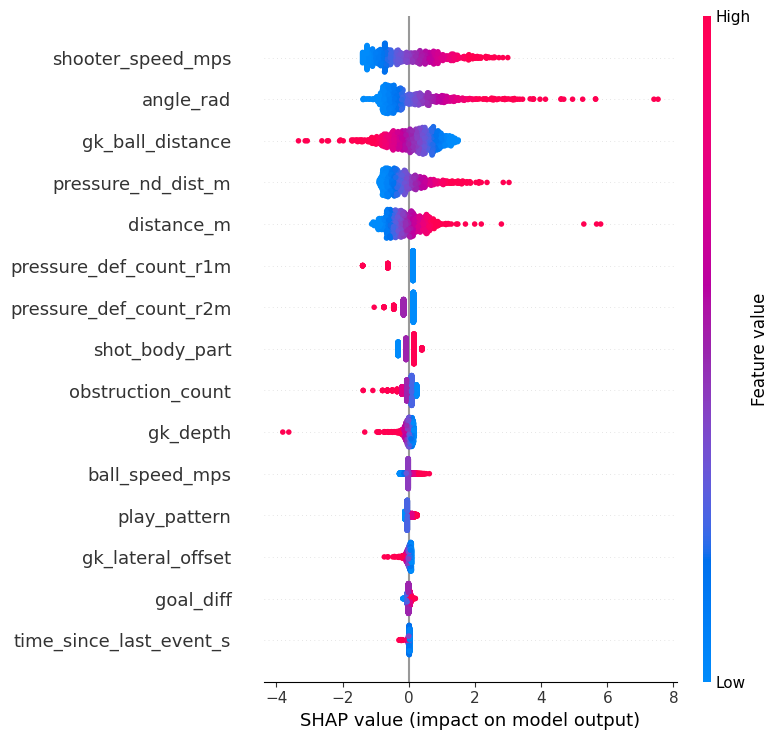

Gemt: shap_logreg_beeswarm.png


In [18]:
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_names, show=False)
plt.savefig('/Users/mariusschonberg/Desktop/Speciale/thesis/figures/shap_logreg_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Gemt: shap_logreg_beeswarm.png')


## 6. Top features

In [19]:
vals = np.abs(shap_values).mean(axis=0)
top = pd.Series(vals, index=feature_names).sort_values(ascending=False)
print(top)


shooter_speed_mps          0.785704
angle_rad                  0.727143
gk_ball_distance           0.594402
pressure_nd_dist_m         0.505749
distance_m                 0.442634
pressure_def_count_r1m     0.208690
pressure_def_count_r2m     0.178273
shot_body_part             0.174211
obstruction_count          0.141233
gk_depth                   0.109189
ball_speed_mps             0.092256
play_pattern               0.072787
gk_lateral_offset          0.056720
goal_diff                  0.034674
time_since_last_event_s    0.025721
dtype: float64
